### Imports

In [1]:
from pathlib import Path
import sys
import os
import json
import random
import hashlib
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

import rasterio

### Paths

In [2]:
PROJECT_ROOT = Path("..").resolve()

RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATASET_DIR = RAW_DIR / "EuroSAT"

SPLITS_DIR = (
    PROJECT_ROOT
    / "data"
    / "splits"
)

FIGURES_DIR = (
    PROJECT_ROOT
    / "figures"
)

SPLITS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root:")
print(PROJECT_ROOT)

print("\nDataset directory:")
print(DATASET_DIR)

Project root:
C:\MyDocuments\GitHub Repository\image-classification-project

Dataset directory:
C:\MyDocuments\GitHub Repository\image-classification-project\data\raw\EuroSAT


### Verify dataset

In [26]:
if not DATASET_DIR.exists():

    raise FileNotFoundError(
        f"Dataset not found:\n{DATASET_DIR}\n\n"
        "Extract EuroSAT.zip into data/raw/ first."
    )

TRAIN_DIR = DATASET_DIR / "train"
VALIDATION_DIR = DATASET_DIR / "val"
TEST_DIR = DATASET_DIR / "test"

for split_name, split_dir in [
    ("train", TRAIN_DIR),
    ("validation", VALIDATION_DIR),
    ("test", TEST_DIR)
]:

    if not split_dir.exists():

        raise FileNotFoundError(
            f"""
Required dataset split not found:

{split_dir}

Expected EuroSAT structure:

EuroSAT/
├── train/
├── val/
└── test/
"""
        )


print("\nDataset found.")

print("Train:")
print(TRAIN_DIR)

print("\nValidation:")
print(VALIDATION_DIR)

print("\nTest:")
print(TEST_DIR)


Dataset found.
Train:
C:\MyDocuments\GitHub Repository\image-classification-project\data\raw\EuroSAT\train

Validation:
C:\MyDocuments\GitHub Repository\image-classification-project\data\raw\EuroSAT\val

Test:
C:\MyDocuments\GitHub Repository\image-classification-project\data\raw\EuroSAT\test


### Class discovery

In [4]:
classes = sorted(
    [
        directory.name
        for directory in TRAIN_DIR.iterdir()
        if directory.is_dir()
    ]
)

print("Classes:")

for index, class_name in enumerate(classes):

    print(
        f"{index}: {class_name}"
    )

Classes:
0: AnnualCrop
1: Forest
2: HerbaceousVegetation
3: Highway
4: Industrial
5: Pasture
6: PermanentCrop
7: Residential
8: River
9: SeaLake


### Verify train/val/test classes

In [27]:
train_classes = sorted(
    [
        directory.name
        for directory in TRAIN_DIR.iterdir()
        if directory.is_dir()
    ]
)

validation_classes = sorted(
    [
        directory.name
        for directory in VALIDATION_DIR.iterdir()
        if directory.is_dir()
    ]
)

test_classes = sorted(
    [
        directory.name
        for directory in TEST_DIR.iterdir()
        if directory.is_dir()
    ]
)

assert train_classes == validation_classes, (
    "Train and validation classes do not match."
)

assert train_classes == test_classes, (
    "Train and test classes do not match."
)


classes = train_classes


print("Classes:")

for index, class_name in enumerate(classes):

    print(
        f"{index}: {class_name}"
    )


print(
    "\nNumber of classes:",
    len(classes)
)

Classes:
0: AnnualCrop
1: Forest
2: HerbaceousVegetation
3: Highway
4: Industrial
5: Pasture
6: PermanentCrop
7: Residential
8: River
9: SeaLake

Number of classes: 10


### Build the complete metadata table

In [28]:
CLASS_TO_INDEX = {
    class_name: index
    for index, class_name in enumerate(classes)
}


def collect_split_records(
    split_dir,
    split_name
):

    records = []

    for class_name in classes:

        class_dir = split_dir / class_name

        if not class_dir.exists():

            raise FileNotFoundError(
                f"Class directory not found:\n{class_dir}"
            )

        for image_path in sorted(
            class_dir.glob("*.tif")
        ):

            records.append(
                {
                    "image_path": str(
                        image_path.resolve()
                    ),

                    "class_name": class_name,

                    "label": CLASS_TO_INDEX[
                        class_name
                    ],

                    "split": split_name
                }
            )

    return records


# ------------------------------------------------------------
# Collect the THREE PROVIDED splits
# ------------------------------------------------------------

train_records = collect_split_records(
    TRAIN_DIR,
    "train"
)

validation_records = collect_split_records(
    VALIDATION_DIR,
    "validation"
)

test_records = collect_split_records(
    TEST_DIR,
    "test"
)


# ------------------------------------------------------------
# Create separate DataFrames
# ------------------------------------------------------------

train_metadata = pd.DataFrame(
    train_records
)

validation_metadata = pd.DataFrame(
    validation_records
)

test_metadata = pd.DataFrame(
    test_records
)


# Combined metadata is useful for inspection
metadata = pd.concat(
    [
        train_metadata,
        validation_metadata,
        test_metadata
    ],
    ignore_index=True
)


print(
    "Total images:",
    len(metadata)
)

print(
    "Training images:",
    len(train_metadata)
)

print(
    "Validation images:",
    len(validation_metadata)
)

print(
    "Test images:",
    len(test_metadata)
)

Total images: 27000
Training images: 16200
Validation images: 5400
Test images: 5400


### Check class distribution

Class distribution:
split                 test  train  validation
class_name                                   
AnnualCrop             596   1791         613
Forest                 608   1787         605
HerbaceousVegetation   573   1799         628
Highway                496   1505         499
Industrial             501   1492         507
Pasture                396   1195         409
PermanentCrop          538   1481         481
Residential            554   1863         583
River                  529   1460         511
SeaLake                609   1827         564

Total images per class:
class_name
AnnualCrop              3000
Forest                  3000
HerbaceousVegetation    3000
Highway                 2500
Industrial              2500
Pasture                 2000
PermanentCrop           2500
Residential             3000
River                   2500
SeaLake                 3000
Name: count, dtype: int64


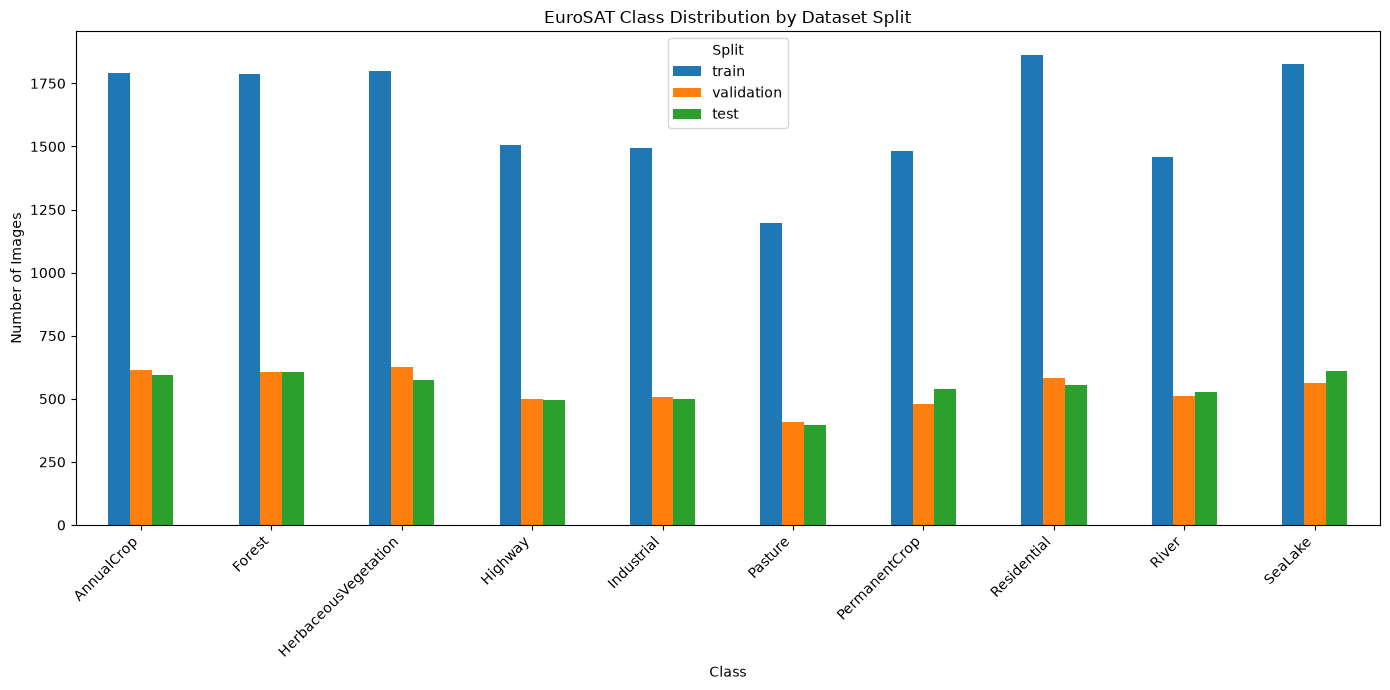

In [29]:
distribution = pd.crosstab(
    metadata["class_name"],
    metadata["split"]
)

print("Class distribution:")
print(distribution)

class_counts = (
    metadata["class_name"]
    .value_counts()
    .sort_index()
)


class_counts = (
    metadata["class_name"]
    .value_counts()
    .sort_index()
)

print(
    "\nTotal images per class:"
)

print(class_counts)

# ============================================================
# CLASS DISTRIBUTION FIGURE
# ============================================================

split_distribution = (
    metadata
    .groupby(
        ["class_name", "split"]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

split_distribution = split_distribution[
    ["train", "validation", "test"]
]


ax = split_distribution.plot(
    kind="bar",
    figsize=(14, 7)
)

ax.set_title(
    "EuroSAT Class Distribution by Dataset Split"
)

ax.set_xlabel(
    "Class"
)

ax.set_ylabel(
    "Number of Images"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Split"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "class_distribution_by_split.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Inspect a GeoTIFF

In [30]:
sample_paths = {
    "train": Path(
        train_metadata.iloc[0]["image_path"]
    ),

    "validation": Path(
        validation_metadata.iloc[0]["image_path"]
    ),

    "test": Path(
        test_metadata.iloc[0]["image_path"]
    )
}


for split_name, sample_path in sample_paths.items():

    print(
        f"\n{'=' * 60}"
    )

    print(
        f"{split_name.upper()} SAMPLE"
    )

    print(
        f"{'=' * 60}"
    )

    print(
        "File:",
        sample_path
    )

    with rasterio.open(
        sample_path
    ) as src:

        print(
            "Width:",
            src.width
        )

        print(
            "Height:",
            src.height
        )

        print(
            "Bands:",
            src.count
        )

        print(
            "Data types:",
            src.dtypes
        )


TRAIN SAMPLE
File: C:\MyDocuments\GitHub Repository\image-classification-project\data\raw\EuroSAT\train\AnnualCrop\AnnualCrop_1.tif
Width: 64
Height: 64
Bands: 13
Data types: ('uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16')

VALIDATION SAMPLE
File: C:\MyDocuments\GitHub Repository\image-classification-project\data\raw\EuroSAT\val\AnnualCrop\AnnualCrop_1008.tif
Width: 64
Height: 64
Bands: 13
Data types: ('uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16')

TEST SAMPLE
File: C:\MyDocuments\GitHub Repository\image-classification-project\data\raw\EuroSAT\test\AnnualCrop\AnnualCrop_1002.tif
Width: 64
Height: 64
Bands: 13
Data types: ('uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16')


### Check every file

In [31]:
# ============================================================
# GEO-TIFF VALIDATION
# ============================================================

bad_files = []

all_images = metadata[
    "image_path"
].tolist()


for image_path in tqdm(
    all_images,
    desc="Checking GeoTIFF files"
):

    try:

        with rasterio.open(
            image_path
        ) as src:

            # ------------------------------------------------
            # Check number of spectral bands
            # ------------------------------------------------

            if src.count != 13:

                bad_files.append(
                    (
                        image_path,
                        f"Expected 13 bands, got {src.count}"
                    )
                )


            # ------------------------------------------------
            # Check image dimensions
            # ------------------------------------------------

            if src.width != 64:

                bad_files.append(
                    (
                        image_path,
                        f"Expected width 64, got {src.width}"
                    )
                )

            if src.height != 64:

                bad_files.append(
                    (
                        image_path,
                        f"Expected height 64, got {src.height}"
                    )
                )


    except Exception as error:

        bad_files.append(
            (
                image_path,
                str(error)
            )
        )


print(
    "\nBad files:",
    len(bad_files)
)


if bad_files:

    print(
        "\nFirst 20 problematic files:"
    )

    for item in bad_files[:20]:

        print(item)

else:

    print(
        "All 27,000 GeoTIFF files passed validation."
    )

Checking GeoTIFF files:   0%|          | 0/27000 [00:00<?, ?it/s]


Bad files: 0
All 27,000 GeoTIFF files passed validation.


### Duplicate detection

In [32]:
# ============================================================
# EXACT DUPLICATE DETECTION
# ============================================================

def file_md5(path):

    hash_md5 = hashlib.md5()

    with open(
        path,
        "rb"
    ) as file:

        for chunk in iter(
            lambda: file.read(1024 * 1024),
            b""
        ):

            hash_md5.update(
                chunk
            )

    return hash_md5.hexdigest()


hash_records = []

for row in tqdm(
    metadata.itertuples(index=False),
    total=len(metadata),
    desc="Checking exact duplicates"
):

    digest = file_md5(
        row.image_path
    )

    hash_records.append(
        {
            "image_path": row.image_path,
            "class_name": row.class_name,
            "split": row.split,
            "md5": digest
        }
    )


hash_metadata = pd.DataFrame(
    hash_records
)


# ------------------------------------------------------------
# Find duplicated file contents
# ------------------------------------------------------------

duplicate_groups = (
    hash_metadata[
        hash_metadata["md5"].duplicated(
            keep=False
        )
    ]
    .sort_values("md5")
)


print(
    "Files involved in exact duplicate groups:",
    len(duplicate_groups)
)


# ------------------------------------------------------------
# Determine whether duplicates cross splits
# ------------------------------------------------------------

cross_split_duplicate_groups = (
    duplicate_groups
    .groupby("md5")["split"]
    .nunique()
)

cross_split_duplicate_hashes = (
    cross_split_duplicate_groups[
        cross_split_duplicate_groups > 1
    ]
)


print(
    "Duplicate groups crossing dataset splits:",
    len(cross_split_duplicate_hashes)
)


if len(cross_split_duplicate_hashes) > 0:

    print(
        "\nWARNING:"
    )

    print(
        "Exact duplicate images occur across train/"
        "validation/test."
    )

    print(
        "These must be investigated before model training."
    )

else:

    print(
        "\nNo exact duplicate groups cross the dataset splits."
    )

Checking exact duplicates:   0%|          | 0/27000 [00:00<?, ?it/s]

Files involved in exact duplicate groups: 0
Duplicate groups crossing dataset splits: 0

No exact duplicate groups cross the dataset splits.


### File split

In [33]:
train_final = train_metadata.copy()

validation_final = validation_metadata.copy()

test_final = test_metadata.copy()


print(
    "Final dataset sizes:"
)

print(
    "Training:",
    len(train_final)
)

print(
    "Validation:",
    len(validation_final)
)

print(
    "Test:",
    len(test_final)
)

print(
    "Total:",
    len(train_final)
    + len(validation_final)
    + len(test_final)
)

Final dataset sizes:
Training: 16200
Validation: 5400
Test: 5400
Total: 27000


### Save the splits

In [34]:
train_final.to_csv(
    SPLITS_DIR / "train.csv",
    index=False
)

validation_final.to_csv(
    SPLITS_DIR / "validation.csv",
    index=False
)

test_final.to_csv(
    SPLITS_DIR / "test.csv",
    index=False
)

print(
    "Training:",
    len(train_final)
)

print(
    "Validation:",
    len(validation_final)
)

print(
    "Test:",
    len(test_final)
)

Training: 16200
Validation: 5400
Test: 5400


### Verify class balance

In [35]:
# ============================================================
# FINAL SPLIT DISTRIBUTION
# ============================================================

split_distribution = pd.DataFrame(
    {
        "train": train_final[
            "class_name"
        ].value_counts(),

        "validation": validation_final[
            "class_name"
        ].value_counts(),

        "test": test_final[
            "class_name"
        ].value_counts()
    }
).sort_index()


print(
    "Images per class in each split:"
)

print(
    split_distribution
)


# ------------------------------------------------------------
# Percentages
# ------------------------------------------------------------

split_percentages = (
    split_distribution
    .div(
        split_distribution.sum(
            axis=0
        ),
        axis=1
    )
    * 100
)


print(
    "\nPercentage distribution:"
)

print(
    split_percentages.round(2)
)


# ------------------------------------------------------------
# Verify total split sizes
# ------------------------------------------------------------

assert len(train_final) == 16200

assert len(validation_final) == 5400

assert len(test_final) == 5400


print(
    "\nSplit sizes verified."
)

print(
    "60% train / 20% validation / 20% test"
)

Images per class in each split:
                      train  validation  test
class_name                                   
AnnualCrop             1791         613   596
Forest                 1787         605   608
HerbaceousVegetation   1799         628   573
Highway                1505         499   496
Industrial             1492         507   501
Pasture                1195         409   396
PermanentCrop          1481         481   538
Residential            1863         583   554
River                  1460         511   529
SeaLake                1827         564   609

Percentage distribution:
                      train  validation   test
class_name                                    
AnnualCrop            11.06       11.35  11.04
Forest                11.03       11.20  11.26
HerbaceousVegetation  11.10       11.63  10.61
Highway                9.29        9.24   9.19
Industrial             9.21        9.39   9.28
Pasture                7.38        7.57   7.33
PermanentCrop 

### Calculate spectral statistics

In [36]:
# ============================================================
# PROJECT PATH SETUP
# ============================================================

import sys
from pathlib import Path

# Project root = one level above the notebooks directory
PROJECT_ROOT = Path.cwd().parent

# Add project root to Python's import path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())

from src.dataset_utils import read_geotiff

CHANNELS = 13

band_sum = np.zeros(
    CHANNELS,
    dtype=np.float64
)

band_squared_sum = np.zeros(
    CHANNELS,
    dtype=np.float64
)

pixel_count = 0


for image_path in tqdm(
    train_final["image_path"],
    desc="Calculating training spectral statistics"
):

    image = read_geotiff(
        image_path
    ).numpy()


    image = image.astype(
        np.float64
    )


    band_sum += image.sum(
        axis=(1, 2)
    )


    band_squared_sum += (
        image ** 2
    ).sum(
        axis=(1, 2)
    )


    pixel_count += (
        image.shape[1]
        * image.shape[2]
    )


# ------------------------------------------------------------
# Calculate mean
# ------------------------------------------------------------

band_mean = (
    band_sum
    / pixel_count
)


# ------------------------------------------------------------
# Calculate variance
# ------------------------------------------------------------

band_variance = (
    band_squared_sum
    / pixel_count
    - band_mean ** 2
)


# ------------------------------------------------------------
# Calculate standard deviation
# ------------------------------------------------------------

band_std = np.sqrt(
    np.maximum(
        band_variance,
        1e-12
    )
)


print(
    "Training-set band means:"
)

print(
    band_mean
)


print(
    "\nTraining-set band standard deviations:"
)

print(
    band_std
)

Project root: C:\MyDocuments\GitHub Repository\image-classification-project
src exists: True


Calculating training spectral statistics:   0%|          | 0/16200 [00:00<?, ?it/s]

Training-set band means:
[1354.40546513 1118.24399958 1042.92983953  947.62620298 1199.47283961
 1999.79090914 2369.22292565 2296.82608323  732.08340178   12.11327804
 1819.01027855 1118.92391149 2594.14080798]

Training-set band standard deviations:
[ 245.71762908  333.00778264  395.09249139  593.75055589  566.4170017
  861.18399006 1086.63139075 1117.98170791  404.91978886    4.77584468
 1002.58768311  761.30323499 1231.58581042]


### Save metadata

In [37]:
metadata_output = {

    "dataset": "EuroSAT",

    "source": (
        "https://huggingface.co/datasets/"
        "Ehzoahis/EuroSAT"
    ),

    "random_seed": 42,

    "num_classes": len(classes),

    "num_bands": 13,

    "image_width": 64,

    "image_height": 64,

    "model_input_size": 224,

    "train_images": len(train_final),

    "validation_images": len(validation_final),

    "test_images": len(test_final),

    "total_images": (
        len(train_final)
        + len(validation_final)
        + len(test_final)
    ),

    "band_mean": band_mean.tolist(),

    "band_std": band_std.tolist(),

    "classes": classes,

    "split_method": (
        "The official train, validation, and test "
        "splits supplied by the Hugging Face EuroSAT "
        "dataset were retained without additional "
        "random splitting."
    ),

    "split_percentages": {
        "train": 60.0,
        "validation": 20.0,
        "test": 20.0
    },

    "leakage_prevention": (
        "The supplied dataset splits were preserved. "
        "Exact duplicate files were checked across "
        "all three splits."
    )
}


with open(
    SPLITS_DIR / "metadata.json",
    "w"
) as file:

    json.dump(
        metadata_output,
        file,
        indent=4
    )


print(
    "Metadata saved to:"
)

print(
    SPLITS_DIR / "metadata.json"
)

Metadata saved to:
C:\MyDocuments\GitHub Repository\image-classification-project\data\splits\metadata.json


### Save final splits

In [38]:
train_final.to_csv(
    SPLITS_DIR / "train.csv",
    index=False
)

validation_final.to_csv(
    SPLITS_DIR / "validation.csv",
    index=False
)

test_final.to_csv(
    SPLITS_DIR / "test.csv",
    index=False
)


print(
    "Split files saved:"
)

print(
    SPLITS_DIR / "train.csv"
)

print(
    SPLITS_DIR / "validation.csv"
)

print(
    SPLITS_DIR / "test.csv"
)

Split files saved:
C:\MyDocuments\GitHub Repository\image-classification-project\data\splits\train.csv
C:\MyDocuments\GitHub Repository\image-classification-project\data\splits\validation.csv
C:\MyDocuments\GitHub Repository\image-classification-project\data\splits\test.csv


### Display representative images

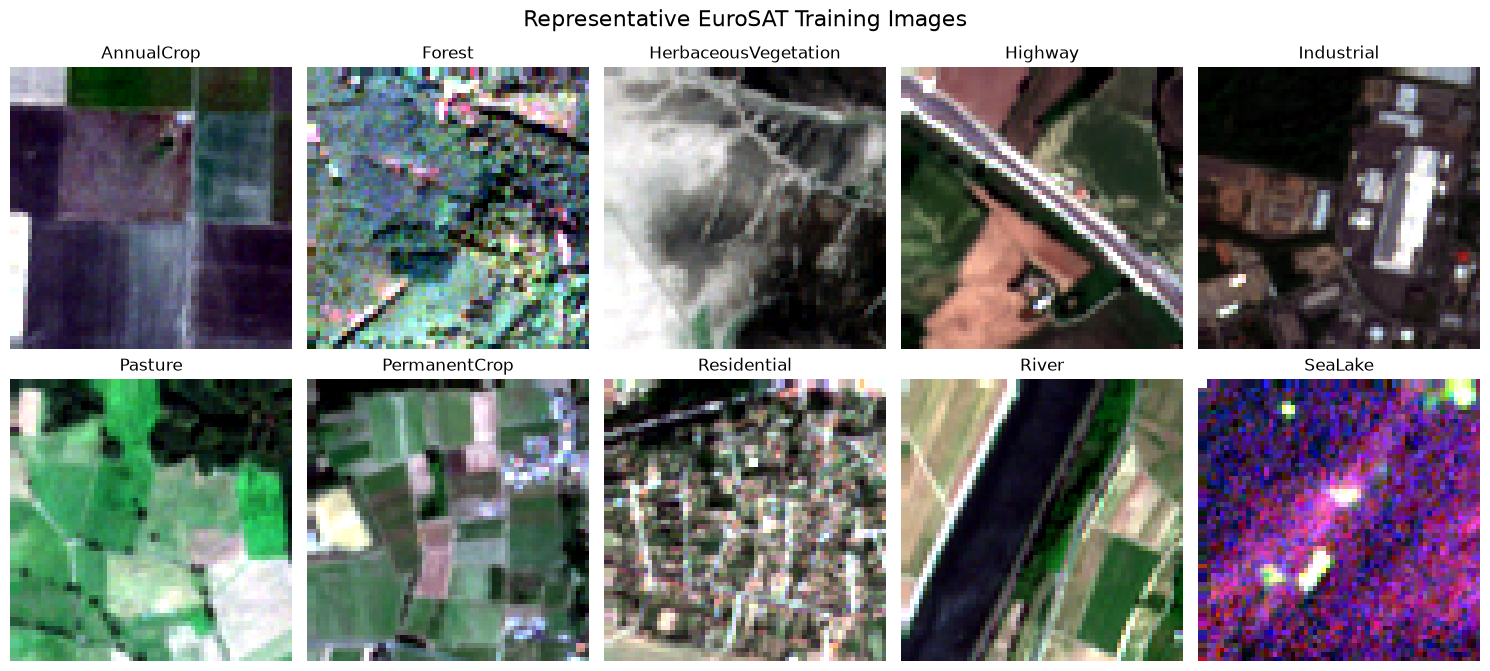

In [39]:
def load_rgb(path):

    with rasterio.open(path) as src:

        image = src.read()


    # EuroSAT Sentinel-2 band mapping:
    #
    # B04 = Red
    # B03 = Green
    # B02 = Blue
    #
    # Zero-based indices:
    # B04 -> 3
    # B03 -> 2
    # B02 -> 1

    red = image[3]

    green = image[2]

    blue = image[1]


    rgb = np.stack(
        [
            red,
            green,
            blue
        ],
        axis=-1
    ).astype(
        np.float32
    )


    # Percentile contrast stretch for visualization

    lower = np.percentile(
        rgb,
        2,
        axis=(0, 1)
    )


    upper = np.percentile(
        rgb,
        98,
        axis=(0, 1)
    )


    rgb = (
        rgb - lower
    ) / (
        upper - lower + 1e-8
    )


    rgb = np.clip(
        rgb,
        0,
        1
    )


    return rgb


fig, axes = plt.subplots(
    2,
    5,
    figsize=(15, 7)
)


for ax, class_name in zip(
    axes.ravel(),
    classes
):

    sample = (
        train_final[
            train_final["class_name"] == class_name
        ]
        .iloc[0]
    )


    rgb = load_rgb(
        sample["image_path"]
    )


    ax.imshow(
        rgb
    )


    ax.set_title(
        class_name
    )


    ax.axis(
        "off"
    )


fig.suptitle(
    "Representative EuroSAT Training Images",
    fontsize=16
)


plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "representative_classes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()